In [3]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [5]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5167,4188-PCPIG,Female,0,Yes,No,57,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),70.35,4124.65,No
5518,9574-RKJIF,Male,0,Yes,Yes,30,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,94.40,2838.7,Yes
6104,7356-AYNJP,Female,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,23.90,97.5,No
2776,7503-QQRVF,Male,1,Yes,No,16,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.30,1178.25,Yes


In [6]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [7]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [8]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
     

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [11]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [19]:
xgb_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', XGBClassifier())])

In [20]:
xgb_pipe.fit(X_train, y_train)

,steps,"[('cleaning', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function bas...001F9EE820EA0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [21]:
y_pred = xgb_pipe.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test, y_pred)*100)

Accuracy: 78.92122072391767


n_estimators = 10 --> Accuracy = 0.7942
n_estimators = 20 --> Accuracy = 0.8020
n_estimators = 50 --> Accuracy = 0.8148
n_estimators = 100 --> Accuracy = 0.8119
n_estimators = 150 --> Accuracy = 0.8077
n_estimators = 200 --> Accuracy = 0.8062
n_estimators = 300 --> Accuracy = 0.7970

Best n_estimators : 50
Best Accuracy : 0.8147622427253371


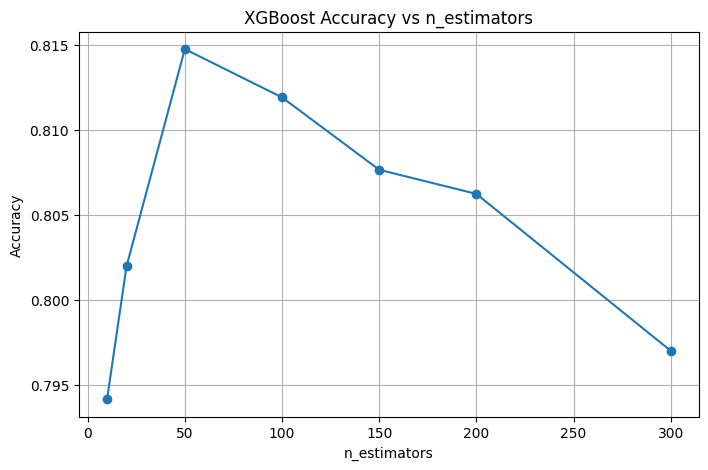

In [25]:
# XGBOOST MODEL
# Different n_estimators values
estimators_list = [10, 20, 50, 100, 150, 200, 300]

# Accuracy store karne ke liye
accuracy_list = []

# Loop
for n in estimators_list:

    # Model create
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=5,
        objective='multi:softmax',
        num_class=3,
        random_state=42
    )

    xgb_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model',model)])
    # Train model
    xgb_pipe.fit(X_train, y_train)

    # Prediction
    y_pred = xgb_pipe.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store accuracy
    accuracy_list.append(acc)

    # Print result
    print(f"n_estimators = {n} --> Accuracy = {acc:.4f}")


# BEST VALUE

best_accuracy = max(accuracy_list)

best_n = estimators_list[accuracy_list.index(best_accuracy)]

print("\nBest n_estimators :", best_n)
print("Best Accuracy :", best_accuracy)


# GRAPH


plt.figure(figsize=(8,5))

plt.plot(estimators_list, accuracy_list, marker='o')

plt.title("XGBoost Accuracy vs n_estimators")

plt.xlabel("n_estimators")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [26]:

# CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.52      0.57       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



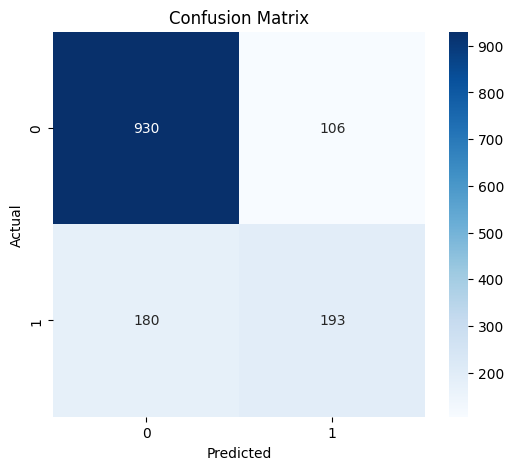

In [27]:

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
     

30
30


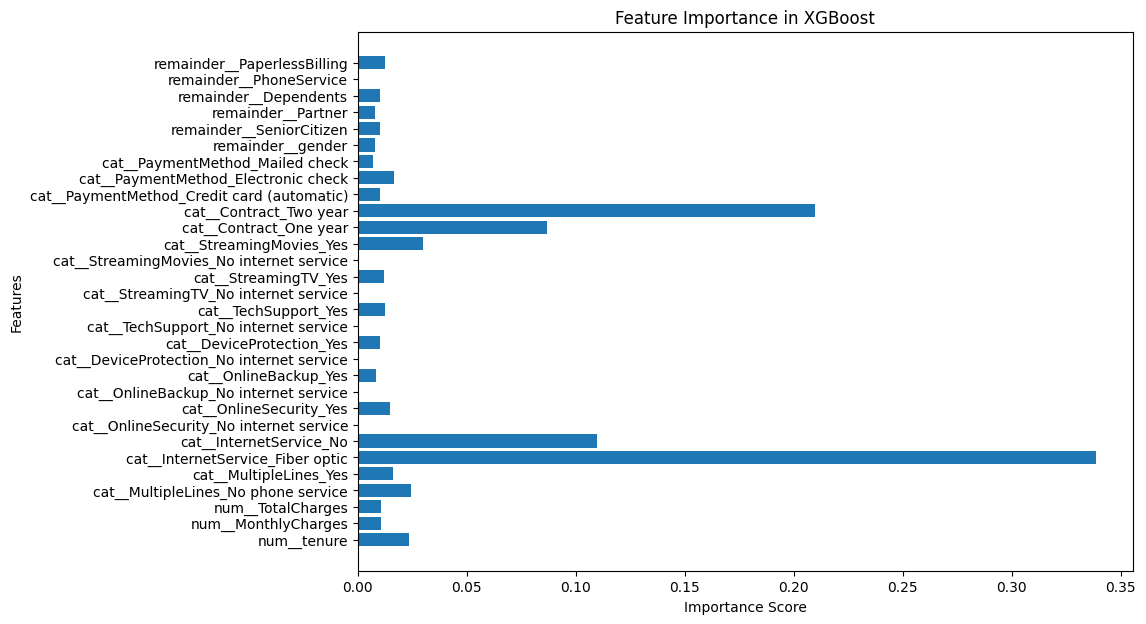

In [29]:
# Trained XGBoost model
model = xgb_pipe.named_steps['model']

# Importance values
importance = model.feature_importances_

# Transformed feature names
feature_names = xgb_pipe.named_steps['preprocessing'].get_feature_names_out()

# Check lengths
print(len(feature_names))
print(len(importance))

# Plot
plt.figure(figsize=(10,7))

plt.barh(feature_names, importance)

plt.title("Feature Importance in XGBoost")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()